In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skmatter.preprocessing import StandardFlexibleScaler
from rdkit import Chem
from rdkit.Chem import MACCSkeys
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from skmatter.decomposition import PCovR
from skmatter.decomposition import KernelPCovR

/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
# conductivity data
Full_data = pd.read_pickle(r"../Databases/Database['Electrical_conductivity', 'Viscosity', 'Specific_density'] With PubChem - Updated 20230720-141035.pkl")

data = Full_data[['compString',
    'Temperature',
    'molarCond_Scm2mol',
    'Viscosity',
    'Specific_density',
    'Electrical_conductivity',
    'Smiles_cation',
    'Smiles_anion'
    ]]

data = data.dropna() # dropna is used to remove/eliminate any data without info
data = data.loc[np.round(data['Temperature'], 0) == 298] # .loc is used to find these values
data = data.reset_index(drop=True) # resetting index
data = data.drop_duplicates(subset=['Smiles_cation', 'Smiles_anion']) # drops duplicat data points
data = data.reset_index(drop=True)

molcond_scalar = StandardFlexibleScaler(with_mean=False, with_std=False)
data['molarCond_Scm2mol'] = molcond_scalar.fit_transform((data['molarCond_Scm2mol'].to_numpy().reshape(-1,1)))

data.loc[data['Smiles_cation'] == 'CC[NH+]1CN(C=C1)C', 'Smiles_cation'] = 'CCN1C=C[N+](=C1)C'

/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [3]:
# Electrostatic groups Bit Matrix

cations = data[['Smiles_cation']] # note: leaving off drop.duplicates here and for anions
anions = data[['Smiles_anion']]
subs_list = pd.read_csv(r"../Databases/IL.SMARTS_4.3.csv",dtype='str',na_values='',na_filter=False) # electrostatic SMARTS strings

# Function to create Bit Vector of electrostatic groups
def substruct_matrix(subs_list, smiles):
    Bit_Matrix = np.zeros((len(smiles),len(subs_list)))
    count_1 = 0 

    for index, row in subs_list.iterrows():
        i = row[subs_list.columns[1]] # 'SMILES Cations/Anions:'
        j = row[subs_list.columns[2]] # 'Other representations:' (relevant resonance structures)
        count_2 = 0

        for k in smiles[smiles.columns[0]]: # iterating through each SMILES string
            mol = Chem.MolFromSmiles(k) # setting molecule for iteration
           
            if (mol.HasSubstructMatch(Chem.MolFromSmarts(i)) == True) | (mol.HasSubstructMatch(Chem.MolFromSmarts(j)) == True): # Checks for substructure match on either structure
                Bit_Matrix[count_2][count_1] = 1 # if match, then this position in Bit_Matrix is 1

            else:
                Bit_Matrix[count_2][count_1] = 0 # if no match, then this position in Bit_Matrix is 0

            count_2 = count_2 + 1
        count_1 = count_1 + 1
        
    return(Bit_Matrix)


Bit_Matrix_Cat = pd.DataFrame(substruct_matrix(subs_list,cations))
Bit_Matrix_An = pd.DataFrame(substruct_matrix(subs_list,anions))

Bit_Matrix_Cat.columns = [str(i) + '_c' for i in (np.arange(0,len(subs_list),1))]
Bit_Matrix_An.columns = [str(i) + '_a' for i in (np.arange(0,len(subs_list),1))]

# Bit Matrix containing + and - electrostatic groups
Bit_Matrix_ES_df = pd.concat([pd.DataFrame(Bit_Matrix_Cat, columns=[str(i) + '_c' for i in (np.arange(0,len(subs_list),1))], index=np.arange(0,182,1)), pd.DataFrame(Bit_Matrix_An, columns=[str(i) + '_a' for i in (np.arange(0,len(subs_list),1))],  index=np.arange(0,182,1))],axis=1, join='inner')
Bit_Matrix_Short = Bit_Matrix_ES_df.loc[:, ((Bit_Matrix_ES_df.sum(axis=0) > 3) & (Bit_Matrix_ES_df.sum(axis=0) < 180))]

/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/skmatter/decomposition/_pcovr.py:264: UserWarning: This class does not automatically center data, and your data mean is greater than the supplied tolerance.
  warnings.warn(
/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PCovR was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PCovR was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PCovR was fitted without feature names
  warnings.warn(


0.7464372100005408

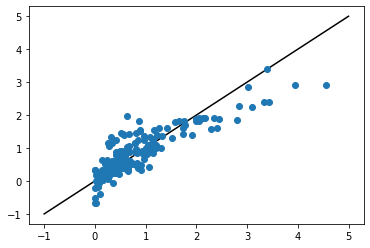

In [4]:
X_train, X_test, y_train, y_test = train_test_split(Bit_Matrix_Short,  data['molarCond_Scm2mol'], test_size=0.30, shuffle=True, random_state=0)

pcovr = PCovR(
    n_components=Bit_Matrix_Short.shape[1],
    regressor=Ridge(alpha=1e-4, fit_intercept=False),
    mixing=0.5,
    random_state=0,
).fit(Bit_Matrix_Short, data['molarCond_Scm2mol'])
T_train_pcovr = pcovr.transform(Bit_Matrix_Short)
T_test_pcovr = pcovr.transform(Bit_Matrix_Short)
T_pcovr = pcovr.transform(Bit_Matrix_Short)
T_pcovr[:,1] = T_pcovr[:,1]

r_pcovr = Ridge(alpha=1e-4, fit_intercept=True, random_state=0).fit(
    T_train_pcovr, data['molarCond_Scm2mol']
)
yp_pcovr = r_pcovr.predict(T_test_pcovr)

plt.scatter(molcond_scalar.inverse_transform(data['molarCond_Scm2mol'].to_numpy().reshape(-1,1)), molcond_scalar.inverse_transform(yp_pcovr.reshape(-1,1)), zorder=1)
plt.plot([-1,5],[-1,5],c='k', zorder=0)

r_pcovr.score(T_test_pcovr, data['molarCond_Scm2mol'])

In [5]:
PCovR_Weights = pd.DataFrame(pcovr.components_[:2].T, index=Bit_Matrix_Short.columns).to_excel('../Data Output/PCovR Weights.xlsx')
# PCovR_Weights.to_excel('PCovR Weights.xlsx')

/var/folders/n0/8fxhskld1wsc76dqzmh0f_9w0000gn/T/ipykernel_86841/3748027917.py:1: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '3.0.1' currently installed).
  PCovR_Weights = pd.DataFrame(pcovr.components_[:2].T, index=Bit_Matrix_Short.columns).to_excel('../Data Output/PCovR Weights.xlsx')


In [6]:
Sorted_TC = pd.concat((pd.DataFrame(T_pcovr), data), axis=1).sort_values(by='molarCond_Scm2mol')
Sorted_T1 = pd.concat((pd.DataFrame(T_pcovr), data), axis=1).sort_values(by=0)
Sorted_T2 = pd.concat((pd.DataFrame(T_pcovr), data), axis=1).sort_values(by=1)

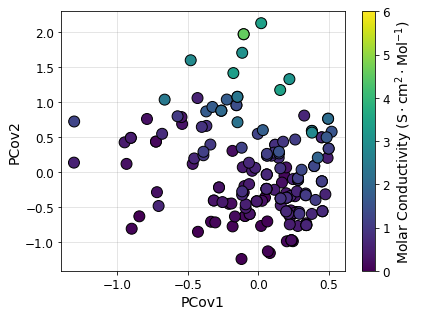

In [8]:
fig,ax2=plt.subplots(1,figsize=(6,4.5), facecolor='white')

ax2.grid(color='gray',axis='both',alpha=0.25)
ax2.set_axisbelow(True)
ax2.tick_params(left=True, bottom=True, labelleft = True, labelbottom=True, labelsize=12)
ax2.set_facecolor('w')

plt.scatter(Sorted_TC[0], Sorted_TC[1], c=Sorted_TC['molarCond_Scm2mol'], edgecolor='k', s=120, linewidth=1, vmin=0, vmax=6)
# ax2.scatter(Sorted_TC[0].iloc[0], Sorted_TC[1].iloc[0], c=Sorted_TC['molarCond_Scm2mol'].iloc[0], s=120, edgecolor='k', linewidths=4, vmin=0, vmax=6)
# ax2.scatter(Sorted_TC[0].iloc[0], Sorted_TC[1].iloc[0], c=Sorted_TC['molarCond_Scm2mol'].iloc[0], s=120, edgecolor='red', linewidths=2, vmin=0, vmax=6)
# ax2.scatter(Sorted_TC[0].iloc[0], Sorted_TC[1].iloc[0], c=Sorted_TC['molarCond_Scm2mol'].iloc[0], s=120, edgecolor='k', linewidths=1, vmin=0, vmax=6)
# ax2.scatter(Sorted_TC[0].iloc[181], Sorted_TC[1].iloc[181], c=Sorted_TC['molarCond_Scm2mol'].iloc[181], s=120, edgecolor='k', linewidths=4, vmin=0, vmax=6)
# ax2.scatter(Sorted_TC[0].iloc[181], Sorted_TC[1].iloc[181], c=Sorted_TC['molarCond_Scm2mol'].iloc[181], s=120, edgecolor='darkorange', linewidths=2, vmin=0, vmax=6)
# ax2.scatter(Sorted_TC[0].iloc[181], Sorted_TC[1].iloc[181], c=Sorted_TC['molarCond_Scm2mol'].iloc[181], s=120, edgecolor='k', linewidths=1, vmin=0, vmax=6)

# ax2.scatter(Sorted_T1[0].iloc[0], Sorted_T1[1].iloc[0], c=Sorted_T1['molarCond_Scm2mol'].iloc[0], s=120, edgecolor='k', linewidths=4, vmin=0, vmax=6)
# ax2.scatter(Sorted_T1[0].iloc[0], Sorted_T1[1].iloc[0], c=Sorted_T1['molarCond_Scm2mol'].iloc[0], s=120, edgecolor='yellow', linewidths=2, vmin=0, vmax=6)
# ax2.scatter(Sorted_T1[0].iloc[0], Sorted_T1[1].iloc[0], c=Sorted_T1['molarCond_Scm2mol'].iloc[0], s=120, edgecolor='k', linewidths=1, vmin=0, vmax=6)
# ax2.scatter(Sorted_T1[0].iloc[181], Sorted_T1[1].iloc[181], c=Sorted_T1['molarCond_Scm2mol'].iloc[181], s=120, edgecolor='k', linewidths=4, vmin=0, vmax=6)
# ax2.scatter(Sorted_T1[0].iloc[181], Sorted_T1[1].iloc[181], c=Sorted_T1['molarCond_Scm2mol'].iloc[181], s=120, edgecolor='green', linewidths=2, vmin=0, vmax=6)
# ax2.scatter(Sorted_T1[0].iloc[181], Sorted_T1[1].iloc[181], c=Sorted_T1['molarCond_Scm2mol'].iloc[181], s=120, edgecolor='k', linewidths=1, vmin=0, vmax=6)

# ax2.scatter(Sorted_T2[0].iloc[0], Sorted_T2[1].iloc[0], c=Sorted_T2['molarCond_Scm2mol'].iloc[0], s=120, edgecolor='k', linewidths=4, vmin=0, vmax=6)
# ax2.scatter(Sorted_T2[0].iloc[0], Sorted_T2[1].iloc[0], c=Sorted_T2['molarCond_Scm2mol'].iloc[0], s=120, edgecolor='blue', linewidths=2, vmin=0, vmax=6)
# ax2.scatter(Sorted_T2[0].iloc[0], Sorted_T2[1].iloc[0], c=Sorted_T2['molarCond_Scm2mol'].iloc[0], s=120, edgecolor='k', linewidths=1, vmin=0, vmax=6)
# ax2.scatter(Sorted_T2[0].iloc[181], Sorted_T2[1].iloc[181], c=Sorted_T2['molarCond_Scm2mol'].iloc[181], s=120, edgecolor='k', linewidths=4, vmin=0, vmax=6)
# ax2.scatter(Sorted_T2[0].iloc[181], Sorted_T2[1].iloc[181], c=Sorted_T2['molarCond_Scm2mol'].iloc[181], s=120, edgecolor='darkviolet', linewidths=2, vmin=0, vmax=6)
# ax2.scatter(Sorted_T2[0].iloc[181], Sorted_T2[1].iloc[181], c=Sorted_T2['molarCond_Scm2mol'].iloc[181], s=120, edgecolor='k', linewidths=1, vmin=0, vmax=6)

plt.xlabel('PCov1', size=14)
plt.ylabel('PCov2', size=14)
#plt.title('5-Fold Cross Validation Conductvities')

cbar = plt.colorbar(location='right', shrink = 1, pad=0.05)
cbar.set_label(label='Molar Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', size=14)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()

#plt.savefig('../Figures/2-dim PCov - Hightlighted.png', dpi=150)
plt.show()

In [9]:
smiles_a = list(data['Smiles_anion'])
smi_a=[Chem.MolFromSmiles(x) for x in smiles_a]
fps_a =  [MACCSkeys.GenMACCSKeys(x) for x in smi_a] # In this example I'll use MACCSKeys

smiles_c = list(data['Smiles_cation'])
smi_c=[Chem.MolFromSmiles(x) for x in smiles_c]
fps_c =  [MACCSkeys.GenMACCSKeys(x) for x in smi_c] # In this example I'll use MACCSKeys

In [10]:
anion_fps = np.array([[0]*167]*len(fps_a))
cation_fps = np.array([[0]*167]*len(fps_c))

for i in range(len(fps_a)):
    for j in range (0,167):
        anion_fps[i][j] = int(fps_a[i][j])

for i in range(len(fps_c)):
    for j in range (0,167):
        cation_fps[i][j] = int(fps_c[i][j])

In [11]:
Cation_maccs_df = pd.DataFrame(cation_fps)
Anion_maccs_df = pd.DataFrame(anion_fps)

Bit_Matrix_MACCS_df = pd.concat((Cation_maccs_df, Anion_maccs_df), axis=1, join='inner')

Bit_Matrix_MACCS_Short = Bit_Matrix_MACCS_df.loc[:, ((Bit_Matrix_MACCS_df.sum(axis=0) > 3) & (Bit_Matrix_MACCS_df.sum(axis=0) < 180))]

/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/skmatter/decomposition/_pcovr.py:264: UserWarning: This class does not automatically center data, and your data mean is greater than the supplied tolerance.
  warnings.warn(


0.8744257626666067

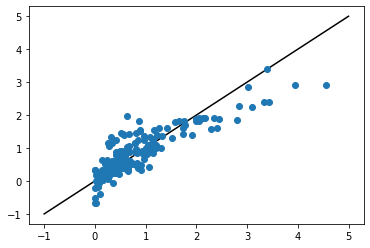

In [12]:
X_train_maccs, X_test_maccs, y_train_maccs, y_test_maccs = train_test_split(Bit_Matrix_MACCS_Short,  data['molarCond_Scm2mol'], test_size=0.30, shuffle=True, random_state=0)

pcovr_maccs = PCovR(
    n_components=Bit_Matrix_MACCS_Short.shape[1],
    regressor=Ridge(alpha=1e-4, fit_intercept=False),
    mixing=0.5,
    random_state=153,
).fit(Bit_Matrix_MACCS_Short, data['molarCond_Scm2mol'])
T_train_pcovr_maccs = pcovr_maccs.transform(Bit_Matrix_MACCS_Short)
T_test_pcovr_maccs = pcovr_maccs.transform(Bit_Matrix_MACCS_Short)
T_pcovr_maccs = pcovr_maccs.transform(Bit_Matrix_MACCS_Short)

r_pcovr_maccs = Ridge(alpha=1e-4, fit_intercept=True, random_state=0).fit(
    T_train_pcovr_maccs, data['molarCond_Scm2mol']
)
yp_pcovr_maccs = r_pcovr_maccs.predict(T_test_pcovr_maccs)

plt.scatter(molcond_scalar.inverse_transform(data['molarCond_Scm2mol'].to_numpy().reshape(-1,1)), molcond_scalar.inverse_transform(yp_pcovr.reshape(-1,1)), zorder=1)
plt.plot([-1,5],[-1,5],c='k', zorder=0)

r_pcovr_maccs.score(T_test_pcovr_maccs, data['molarCond_Scm2mol'])

In [13]:
Sorted_TC_Maccs = pd.concat((pd.DataFrame(T_pcovr_maccs), data), axis=1).sort_values(by='molarCond_Scm2mol')

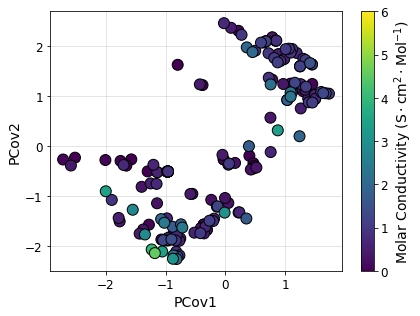

In [14]:
fig,ax2=plt.subplots(1,figsize=(6,4.5), facecolor='white')

ax2.grid(color='gray',axis='both',alpha=0.25)
ax2.set_axisbelow(True)
ax2.tick_params(left=True, bottom=True, labelleft = True, labelbottom=True, labelsize=12)
ax2.set_facecolor('w')

plt.scatter(Sorted_TC_Maccs[0], Sorted_TC_Maccs[1], c=Sorted_TC_Maccs['molarCond_Scm2mol'], edgecolors='k', s=120, vmin=0, vmax=6)

# ax2.scatter(Sorted_TC_Maccs[0].loc[Sorted_TC.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_TC.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_TC.iloc[0].name], s=120, edgecolor='k', linewidths=4, vmin=0, vmax=6)
# ax2.scatter(Sorted_TC_Maccs[0].loc[Sorted_TC.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_TC.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_TC.iloc[0].name], s=120, edgecolor='red', linewidths=2, vmin=0, vmax=6)
# ax2.scatter(Sorted_TC_Maccs[0].loc[Sorted_TC.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_TC.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_TC.iloc[0].name], s=120, edgecolor='k', linewidths=1, vmin=0, vmax=6)
# ax2.scatter(Sorted_TC_Maccs[0].loc[Sorted_TC.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_TC.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_TC.iloc[181].name], s=120, edgecolor='k', linewidths=4, vmin=0, vmax=6)
# ax2.scatter(Sorted_TC_Maccs[0].loc[Sorted_TC.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_TC.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_TC.iloc[181].name], s=120, edgecolor='darkorange', linewidths=2, vmin=0, vmax=6)
# ax2.scatter(Sorted_TC_Maccs[0].loc[Sorted_TC.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_TC.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_TC.iloc[181].name], s=120, edgecolor='k', linewidths=1, vmin=0, vmax=6)

# ax2.scatter(Sorted_TC_Maccs[0].loc[Sorted_T1.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_T1.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T1.iloc[0].name], s=120, edgecolor='k', linewidths=4, vmin=0, vmax=6)
# ax2.scatter(Sorted_TC_Maccs[0].loc[Sorted_T1.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_T1.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T1.iloc[0].name], s=120, edgecolor='yellow', linewidths=2, vmin=0, vmax=6)
# ax2.scatter(Sorted_TC_Maccs[0].loc[Sorted_T1.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_T1.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T1.iloc[0].name], s=120, edgecolor='k', linewidths=1, vmin=0, vmax=6)
# ax2.scatter(Sorted_TC_Maccs[0].loc[Sorted_T1.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_T1.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T1.iloc[181].name], s=120, edgecolor='k', linewidths=4, vmin=0, vmax=6)
# ax2.scatter(Sorted_TC_Maccs[0].loc[Sorted_T1.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_T1.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T1.iloc[181].name], s=120, edgecolor='green', linewidths=2, vmin=0, vmax=6)
# ax2.scatter(Sorted_TC_Maccs[0].loc[Sorted_T1.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_T1.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T1.iloc[181].name], s=120, edgecolor='k', linewidths=1, vmin=0, vmax=6)

# ax2.scatter(Sorted_TC_Maccs[0].loc[Sorted_T2.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_T2.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T2.iloc[0].name], s=120, edgecolor='k', linewidths=4, vmin=0, vmax=6)
# ax2.scatter(Sorted_TC_Maccs[0].loc[Sorted_T2.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_T2.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T2.iloc[0].name], s=120, edgecolor='blue', linewidths=2, vmin=0, vmax=6)
# ax2.scatter(Sorted_TC_Maccs[0].loc[Sorted_T2.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_T2.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T2.iloc[0].name], s=120, edgecolor='k', linewidths=1, vmin=0, vmax=6)
# ax2.scatter(Sorted_TC_Maccs[0].loc[Sorted_T2.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_T2.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T2.iloc[181].name], s=120, edgecolor='k', linewidths=4, vmin=0, vmax=6)
# ax2.scatter(Sorted_TC_Maccs[0].loc[Sorted_T2.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_T2.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T2.iloc[181].name], s=120, edgecolor='white', linewidths=2, vmin=0, vmax=6)
# ax2.scatter(Sorted_TC_Maccs[0].loc[Sorted_T2.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_T2.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T2.iloc[181].name], s=120, edgecolor='k', linewidths=1, vmin=0, vmax=6)

plt.xlabel('PCov1', size=14)
plt.ylabel('PCov2', size=14)
#plt.title('5-Fold Cross Validation Conductvities')

cbar = plt.colorbar(location='right', shrink = 1, pad=0.05)
cbar.set_label(label='Molar Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', size=14)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()

#plt.savefig('../Final Figures/2-dim PCov MACCS - Hightlighted.png', dpi=600)
plt.show()

/var/folders/n0/8fxhskld1wsc76dqzmh0f_9w0000gn/T/ipykernel_86841/2661740943.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


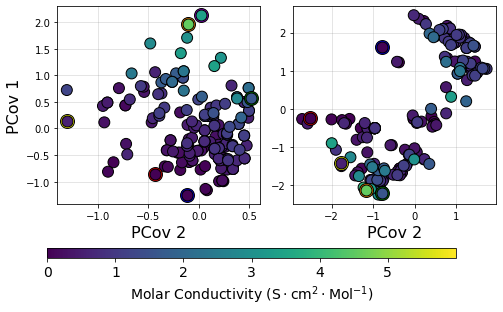

In [15]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(7.0866, 3.5433), facecolor='white')

for axes in axs:
    axes.grid(color='gray',axis='both',alpha=0.25)
    axes.set_axisbelow(True)
    #axes.tick_params(left=False, bottom=False, labelleft = False, labelbottom=False, labelsize=14)
    axes.set_facecolor('white')
    axes.set_xlabel('PCov 2', size=16)

axs[0].scatter(Sorted_TC[0], Sorted_TC[1], c=Sorted_TC['molarCond_Scm2mol'], edgecolor='k', s=120, linewidth=1, vmin=0, vmax=6)
axs[0].scatter(Sorted_TC[0].iloc[0], Sorted_TC[1].iloc[0], c=Sorted_TC['molarCond_Scm2mol'].iloc[0], s=120, edgecolor='k', linewidths=4, vmin=0, vmax=6)
axs[0].scatter(Sorted_TC[0].iloc[0], Sorted_TC[1].iloc[0], c=Sorted_TC['molarCond_Scm2mol'].iloc[0], s=120, edgecolor='red', linewidths=2, vmin=0, vmax=6)
axs[0].scatter(Sorted_TC[0].iloc[0], Sorted_TC[1].iloc[0], c=Sorted_TC['molarCond_Scm2mol'].iloc[0], s=120, edgecolor='k', linewidths=1, vmin=0, vmax=6)
axs[0].scatter(Sorted_TC[0].iloc[181], Sorted_TC[1].iloc[181], c=Sorted_TC['molarCond_Scm2mol'].iloc[181], s=120, edgecolor='k', linewidths=4, vmin=0, vmax=6)
axs[0].scatter(Sorted_TC[0].iloc[181], Sorted_TC[1].iloc[181], c=Sorted_TC['molarCond_Scm2mol'].iloc[181], s=120, edgecolor='darkorange', linewidths=2, vmin=0, vmax=6)
axs[0].scatter(Sorted_TC[0].iloc[181], Sorted_TC[1].iloc[181], c=Sorted_TC['molarCond_Scm2mol'].iloc[181], s=120, edgecolor='k', linewidths=1, vmin=0, vmax=6)

axs[0].scatter(Sorted_T1[0].iloc[0], Sorted_T1[1].iloc[0], c=Sorted_T1['molarCond_Scm2mol'].iloc[0], s=120, edgecolor='k', linewidths=4, vmin=0, vmax=6)
axs[0].scatter(Sorted_T1[0].iloc[0], Sorted_T1[1].iloc[0], c=Sorted_T1['molarCond_Scm2mol'].iloc[0], s=120, edgecolor='yellow', linewidths=2, vmin=0, vmax=6)
axs[0].scatter(Sorted_T1[0].iloc[0], Sorted_T1[1].iloc[0], c=Sorted_T1['molarCond_Scm2mol'].iloc[0], s=120, edgecolor='k', linewidths=1, vmin=0, vmax=6)
axs[0].scatter(Sorted_T1[0].iloc[181], Sorted_T1[1].iloc[181], c=Sorted_T1['molarCond_Scm2mol'].iloc[181], s=120, edgecolor='k', linewidths=4, vmin=0, vmax=6)
axs[0].scatter(Sorted_T1[0].iloc[181], Sorted_T1[1].iloc[181], c=Sorted_T1['molarCond_Scm2mol'].iloc[181], s=120, edgecolor='green', linewidths=2, vmin=0, vmax=6)
axs[0].scatter(Sorted_T1[0].iloc[181], Sorted_T1[1].iloc[181], c=Sorted_T1['molarCond_Scm2mol'].iloc[181], s=120, edgecolor='k', linewidths=1, vmin=0, vmax=6)

axs[0].scatter(Sorted_T2[0].iloc[0], Sorted_T2[1].iloc[0], c=Sorted_T2['molarCond_Scm2mol'].iloc[0], s=120, edgecolor='k', linewidths=4, vmin=0, vmax=6)
axs[0].scatter(Sorted_T2[0].iloc[0], Sorted_T2[1].iloc[0], c=Sorted_T2['molarCond_Scm2mol'].iloc[0], s=120, edgecolor='blue', linewidths=2, vmin=0, vmax=6)
axs[0].scatter(Sorted_T2[0].iloc[0], Sorted_T2[1].iloc[0], c=Sorted_T2['molarCond_Scm2mol'].iloc[0], s=120, edgecolor='k', linewidths=1, vmin=0, vmax=6)
axs[0].scatter(Sorted_T2[0].iloc[181], Sorted_T2[1].iloc[181], c=Sorted_T2['molarCond_Scm2mol'].iloc[181], s=120, edgecolor='k', linewidths=4, vmin=0, vmax=6)
axs[0].scatter(Sorted_T2[0].iloc[181], Sorted_T2[1].iloc[181], c=Sorted_T2['molarCond_Scm2mol'].iloc[181], s=120, edgecolor='darkviolet', linewidths=2, vmin=0, vmax=6)
axs[0].scatter(Sorted_T2[0].iloc[181], Sorted_T2[1].iloc[181], c=Sorted_T2['molarCond_Scm2mol'].iloc[181], s=120, edgecolor='k', linewidths=1, vmin=0, vmax=6)

im = axs[1].scatter(Sorted_TC_Maccs[0], Sorted_TC_Maccs[1], c=Sorted_TC_Maccs['molarCond_Scm2mol'], edgecolors='k', s=120, vmin=0, vmax=6)

axs[1].scatter(Sorted_TC_Maccs[0].loc[Sorted_TC.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_TC.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_TC.iloc[0].name], s=120, edgecolor='k', linewidths=4, vmin=0, vmax=6)
axs[1].scatter(Sorted_TC_Maccs[0].loc[Sorted_TC.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_TC.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_TC.iloc[0].name], s=120, edgecolor='red', linewidths=2, vmin=0, vmax=6)
axs[1].scatter(Sorted_TC_Maccs[0].loc[Sorted_TC.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_TC.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_TC.iloc[0].name], s=120, edgecolor='k', linewidths=1, vmin=0, vmax=6)
axs[1].scatter(Sorted_TC_Maccs[0].loc[Sorted_TC.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_TC.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_TC.iloc[181].name], s=120, edgecolor='k', linewidths=4, vmin=0, vmax=6)
axs[1].scatter(Sorted_TC_Maccs[0].loc[Sorted_TC.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_TC.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_TC.iloc[181].name], s=120, edgecolor='darkorange', linewidths=2, vmin=0, vmax=6)
axs[1].scatter(Sorted_TC_Maccs[0].loc[Sorted_TC.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_TC.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_TC.iloc[181].name], s=120, edgecolor='k', linewidths=1, vmin=0, vmax=6)

axs[1].scatter(Sorted_TC_Maccs[0].loc[Sorted_T1.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_T1.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T1.iloc[0].name], s=120, edgecolor='k', linewidths=4, vmin=0, vmax=6)
axs[1].scatter(Sorted_TC_Maccs[0].loc[Sorted_T1.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_T1.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T1.iloc[0].name], s=120, edgecolor='yellow', linewidths=2, vmin=0, vmax=6)
axs[1].scatter(Sorted_TC_Maccs[0].loc[Sorted_T1.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_T1.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T1.iloc[0].name], s=120, edgecolor='k', linewidths=1, vmin=0, vmax=6)
axs[1].scatter(Sorted_TC_Maccs[0].loc[Sorted_T1.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_T1.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T1.iloc[181].name], s=120, edgecolor='k', linewidths=4, vmin=0, vmax=6)
axs[1].scatter(Sorted_TC_Maccs[0].loc[Sorted_T1.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_T1.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T1.iloc[181].name], s=120, edgecolor='green', linewidths=2, vmin=0, vmax=6)
axs[1].scatter(Sorted_TC_Maccs[0].loc[Sorted_T1.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_T1.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T1.iloc[181].name], s=120, edgecolor='k', linewidths=1, vmin=0, vmax=6)

axs[1].scatter(Sorted_TC_Maccs[0].loc[Sorted_T2.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_T2.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T2.iloc[0].name], s=120, edgecolor='k', linewidths=4, vmin=0, vmax=6)
axs[1].scatter(Sorted_TC_Maccs[0].loc[Sorted_T2.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_T2.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T2.iloc[0].name], s=120, edgecolor='blue', linewidths=2, vmin=0, vmax=6)
axs[1].scatter(Sorted_TC_Maccs[0].loc[Sorted_T2.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_T2.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T2.iloc[0].name], s=120, edgecolor='k', linewidths=1, vmin=0, vmax=6)
# axs[1].scatter(Sorted_TC_Maccs[0].loc[Sorted_T2.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_T2.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T2.iloc[181].name], s=120, edgecolor='k', linewidths=4, vmin=0, vmax=6)
# axs[1].scatter(Sorted_TC_Maccs[0].loc[Sorted_T2.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_T2.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T2.iloc[181].name], s=120, edgecolor='white', linewidths=2, vmin=0, vmax=6)
# axs[1].scatter(Sorted_TC_Maccs[0].loc[Sorted_T2.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_T2.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T2.iloc[181].name], s=120, edgecolor='k', linewidths=1, vmin=0, vmax=6)

axs[0].set_ylabel('PCov 1', size=16)

cb_ax = fig.add_axes([0.1, -0.03 , 0.8, 0.04])
cbar = fig.colorbar(im, cax=cb_ax, shrink = 1, pad=0.05, orientation='horizontal')
cbar.set_label(label='Molar Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', size=14)
cbar.set_ticks([0,1,2,3,4,5])
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()

#plt.savefig('../Final Figures/2-panel PCov - Highlighted.png', dpi=600, bbox_inches='tight')

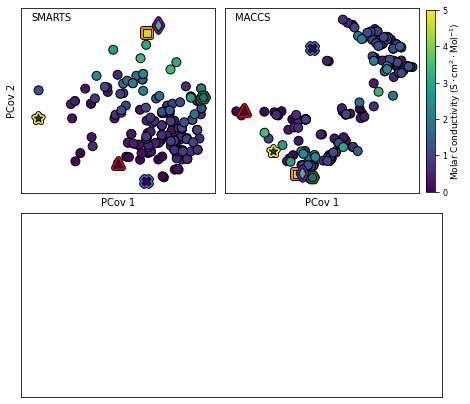

In [16]:
#fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(7.0866, 3.5433), facecolor='white')
fig, axs = plt.subplot_mosaic("AB;CC", figsize=(6.5, 6), facecolor='white')

for axes in ['A','B']:
    axs[axes].grid(color='gray',axis='both',alpha=0.25)
    axs[axes].set_axisbelow(True)
    #axes.tick_params(left=False, bottom=False, labelleft = False, labelbottom=False, labelsize=14)
    axs[axes].set_facecolor('white')
    axs[axes].set_xlabel('PCov 1', size=10)
    axs[axes].set_xticks([])
    axs[axes].set_yticks([])

size_s = 80

axs['A'].set_ylabel('PCov 2', size=10)

axs['A'].scatter(Sorted_TC[0], Sorted_TC[1], c=Sorted_TC['molarCond_Scm2mol'], edgecolor='k', s=size_s, linewidth=1, vmin=0, vmax=5)
axs['A'].scatter(Sorted_TC[0].iloc[0], Sorted_TC[1].iloc[0], c=Sorted_TC['molarCond_Scm2mol'].iloc[0], s=size_s, edgecolor='k', linewidths=6, vmin=0, vmax=5, marker='^')
axs['A'].scatter(Sorted_TC[0].iloc[0], Sorted_TC[1].iloc[0], c=Sorted_TC['molarCond_Scm2mol'].iloc[0], s=size_s, edgecolor='red', linewidths=4, vmin=0, vmax=5, marker='^')
axs['A'].scatter(Sorted_TC[0].iloc[0], Sorted_TC[1].iloc[0], c=Sorted_TC['molarCond_Scm2mol'].iloc[0], s=size_s, edgecolor='k', linewidths=1, vmin=0, vmax=5, marker='^')
axs['A'].scatter(Sorted_TC[0].iloc[181], Sorted_TC[1].iloc[181], c=Sorted_TC['molarCond_Scm2mol'].iloc[181], s=size_s, edgecolor='k', linewidths=6, vmin=0, vmax=5, marker='s')
axs['A'].scatter(Sorted_TC[0].iloc[181], Sorted_TC[1].iloc[181], c=Sorted_TC['molarCond_Scm2mol'].iloc[181], s=size_s, edgecolor='darkorange', linewidths=4, vmin=0, vmax=5, marker='s')
axs['A'].scatter(Sorted_TC[0].iloc[181], Sorted_TC[1].iloc[181], c=Sorted_TC['molarCond_Scm2mol'].iloc[181], s=size_s, edgecolor='k', linewidths=1, vmin=0, vmax=5, marker='s')

axs['A'].scatter(Sorted_T1[0].iloc[0], Sorted_T1[1].iloc[0], c=Sorted_T1['molarCond_Scm2mol'].iloc[0], s=size_s, edgecolor='k', linewidths=6, vmin=0, vmax=5, marker='*')
axs['A'].scatter(Sorted_T1[0].iloc[0], Sorted_T1[1].iloc[0], c=Sorted_T1['molarCond_Scm2mol'].iloc[0], s=size_s, edgecolor='yellow', linewidths=4, vmin=0, vmax=5, marker='*')
axs['A'].scatter(Sorted_T1[0].iloc[0], Sorted_T1[1].iloc[0], c=Sorted_T1['molarCond_Scm2mol'].iloc[0], s=size_s, edgecolor='k', linewidths=1, vmin=0, vmax=5, marker='*')
axs['A'].scatter(Sorted_T1[0].iloc[181], Sorted_T1[1].iloc[181], c=Sorted_T1['molarCond_Scm2mol'].iloc[181], s=size_s, edgecolor='k', linewidths=6, vmin=0, vmax=5, marker='H')
axs['A'].scatter(Sorted_T1[0].iloc[181], Sorted_T1[1].iloc[181], c=Sorted_T1['molarCond_Scm2mol'].iloc[181], s=size_s, edgecolor='green', linewidths=4, vmin=0, vmax=5, marker='H')
axs['A'].scatter(Sorted_T1[0].iloc[181], Sorted_T1[1].iloc[181], c=Sorted_T1['molarCond_Scm2mol'].iloc[181], s=size_s, edgecolor='k', linewidths=1, vmin=0, vmax=5, marker='H')

axs['A'].scatter(Sorted_T2[0].iloc[0], Sorted_T2[1].iloc[0], c=Sorted_T2['molarCond_Scm2mol'].iloc[0], s=size_s, edgecolor='k', linewidths=6, vmin=0, vmax=5, marker='X')
axs['A'].scatter(Sorted_T2[0].iloc[0], Sorted_T2[1].iloc[0], c=Sorted_T2['molarCond_Scm2mol'].iloc[0], s=size_s, edgecolor='royalblue', linewidths=4, vmin=0, vmax=5, marker='X')
axs['A'].scatter(Sorted_T2[0].iloc[0], Sorted_T2[1].iloc[0], c=Sorted_T2['molarCond_Scm2mol'].iloc[0], s=size_s, edgecolor='k', linewidths=1, vmin=0, vmax=5, marker='X')
axs['A'].scatter(Sorted_T2[0].iloc[181], Sorted_T2[1].iloc[181], c=Sorted_T2['molarCond_Scm2mol'].iloc[181], s=size_s, edgecolor='k', linewidths=6, vmin=0, vmax=5, marker='d')
axs['A'].scatter(Sorted_T2[0].iloc[181], Sorted_T2[1].iloc[181], c=Sorted_T2['molarCond_Scm2mol'].iloc[181], s=size_s, edgecolor='darkviolet', linewidths=4, vmin=0, vmax=5, marker='d')
axs['A'].scatter(Sorted_T2[0].iloc[181], Sorted_T2[1].iloc[181], c=Sorted_T2['molarCond_Scm2mol'].iloc[181], s=size_s, edgecolor='k', linewidths=1, vmin=0, vmax=5, marker='d')

im = axs['B'].scatter(Sorted_TC_Maccs[0], Sorted_TC_Maccs[1], c=Sorted_TC_Maccs['molarCond_Scm2mol'], edgecolors='k', s=size_s, vmin=0, vmax=5)

axs['B'].scatter(Sorted_TC_Maccs[0].loc[Sorted_TC.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_TC.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_TC.iloc[0].name], s=size_s, edgecolor='k', linewidths=6, vmin=0, vmax=5, marker='^')
axs['B'].scatter(Sorted_TC_Maccs[0].loc[Sorted_TC.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_TC.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_TC.iloc[0].name], s=size_s, edgecolor='red', linewidths=4, vmin=0, vmax=5, marker='^')
axs['B'].scatter(Sorted_TC_Maccs[0].loc[Sorted_TC.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_TC.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_TC.iloc[0].name], s=size_s, edgecolor='k', linewidths=1, vmin=0, vmax=5, marker='^')
axs['B'].scatter(Sorted_TC_Maccs[0].loc[Sorted_TC.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_TC.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_TC.iloc[181].name], s=size_s, edgecolor='k', linewidths=6, vmin=0, vmax=5, marker='s')
axs['B'].scatter(Sorted_TC_Maccs[0].loc[Sorted_TC.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_TC.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_TC.iloc[181].name], s=size_s, edgecolor='darkorange', linewidths=4, vmin=0, vmax=5, marker='s')
axs['B'].scatter(Sorted_TC_Maccs[0].loc[Sorted_TC.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_TC.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_TC.iloc[181].name], s=size_s, edgecolor='k', linewidths=1, vmin=0, vmax=5, marker='s')

axs['B'].scatter(Sorted_TC_Maccs[0].loc[Sorted_T1.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_T1.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T1.iloc[0].name], s=size_s, edgecolor='k', linewidths=6, vmin=0, vmax=5, marker='*')
axs['B'].scatter(Sorted_TC_Maccs[0].loc[Sorted_T1.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_T1.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T1.iloc[0].name], s=size_s, edgecolor='yellow', linewidths=4, vmin=0, vmax=5, marker='*')
axs['B'].scatter(Sorted_TC_Maccs[0].loc[Sorted_T1.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_T1.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T1.iloc[0].name], s=size_s, edgecolor='k', linewidths=1, vmin=0, vmax=5, marker='*')
axs['B'].scatter(Sorted_TC_Maccs[0].loc[Sorted_T1.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_T1.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T1.iloc[181].name], s=size_s, edgecolor='k', linewidths=6, vmin=0, vmax=5, marker='H')
axs['B'].scatter(Sorted_TC_Maccs[0].loc[Sorted_T1.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_T1.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T1.iloc[181].name], s=size_s, edgecolor='green', linewidths=4, vmin=0, vmax=5, marker='H')
axs['B'].scatter(Sorted_TC_Maccs[0].loc[Sorted_T1.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_T1.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T1.iloc[181].name], s=size_s, edgecolor='k', linewidths=1, vmin=0, vmax=5, marker='H')

axs['B'].scatter(Sorted_TC_Maccs[0].loc[Sorted_T2.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_T2.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T2.iloc[0].name], s=size_s, edgecolor='k', linewidths=6, vmin=0, vmax=5, marker='X')
axs['B'].scatter(Sorted_TC_Maccs[0].loc[Sorted_T2.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_T2.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T2.iloc[0].name], s=size_s, edgecolor='royalblue', linewidths=4, vmin=0, vmax=5, marker='X')
axs['B'].scatter(Sorted_TC_Maccs[0].loc[Sorted_T2.iloc[0].name], Sorted_TC_Maccs[1].loc[Sorted_T2.iloc[0].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T2.iloc[0].name], s=size_s, edgecolor='k', linewidths=1, vmin=0, vmax=5, marker='X')
axs['B'].scatter(Sorted_TC_Maccs[0].loc[Sorted_T2.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_T2.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T2.iloc[181].name], s=size_s, edgecolor='k', linewidths=6, vmin=0, vmax=5, marker='d')
axs['B'].scatter(Sorted_TC_Maccs[0].loc[Sorted_T2.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_T2.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T2.iloc[181].name], s=size_s, edgecolor='darkviolet', linewidths=4, vmin=0, vmax=5, marker='d')
axs['B'].scatter(Sorted_TC_Maccs[0].loc[Sorted_T2.iloc[181].name], Sorted_TC_Maccs[1].loc[Sorted_T2.iloc[181].name], c=Sorted_TC_Maccs['molarCond_Scm2mol'].loc[Sorted_T2.iloc[181].name], s=size_s, edgecolor='k', linewidths=1, vmin=0, vmax=5, marker='d')

axs['C'].set_xticks([])
axs['C'].set_yticks([])
axs['A'].set_xlim(-1.5,0.65)
axs['A'].set_ylim(-1.5,2.5)
axs['A'].annotate('SMARTS', xy=(0.05,0.975), xycoords='axes fraction', size=10, ha='left', va='top')

axs['B'].set_xlim(-3.0,1.9)
axs['B'].set_ylim(-2.7,2.8)
axs['B'].annotate('MACCS', xy=(0.05,0.975), xycoords='axes fraction', size=10, ha='left', va='top')

#plt.subplots_adjust(wspace=0, hspace=0)

cb_ax = fig.add_axes([0.915, 0.525 , 0.02, 0.42])
cbar = fig.colorbar(im, cax=cb_ax, shrink = 1, pad=0, orientation='vertical')
cbar.set_label(label='Molar Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', size=9, labelpad=1)
cbar.set_ticks([0,1,2,3,4,5])
cbar.ax.tick_params(labelsize=8)

plt.subplots_adjust(left=0.05, right=0.9, 
                    top=0.95, bottom=0.05, 
                    wspace=0.05, hspace=0.1)

plt.figure(1).axes[2].set_position([0.05,0.05,0.9,0.425])

#plt.savefig('../Final Figures/2-panel PCov - v8.tif', dpi=1200)

plt.show()

In [17]:
import plotly.express as px
import pandas as pd

Sorted_TC_Maccs['Above 1'] = Sorted_TC_Maccs['molarCond_Scm2mol'] >= 1

# Create an interactive line plot
fig = px.scatter(Sorted_TC_Maccs, x=0, y=1, title="MACCS PCovR", hover_name='compString', color='Above 1', size='molarCond_Scm2mol', width=700, height=600)
fig.update_layout(showlegend=False)
fig.show()




In [18]:
import plotly.express as px
import pandas as pd

Sorted_TC['Above 1'] = Sorted_TC['molarCond_Scm2mol'] >= 1

# Create an interactive line plot
fig = px.scatter(Sorted_TC, x=0, y=1, title="SMARTS PCovR", hover_name='compString', color='Above 1', size='molarCond_Scm2mol', width=700, height=600)
fig.update_layout(showlegend=False)
fig.show()




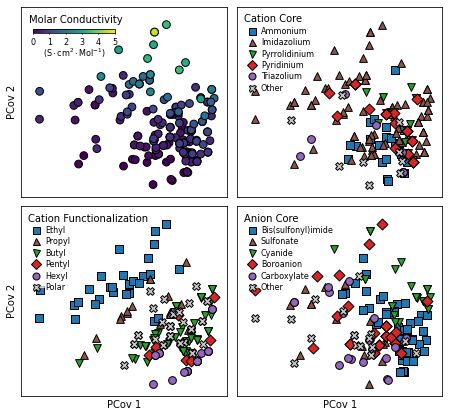

In [ ]:
mark_size = 60

#fig,ax2=plt.subplot_mosaic('AB',figsize=(7.0866, 2.75), facecolor='white')
fig,ax2=plt.subplot_mosaic('AB;CD',figsize=(6.5, 6), facecolor='white')

an_cat_labels = Bit_Matrix_Short.copy()

ax2['B'].grid(color='gray',axis='both',alpha=0.0)
ax2['B'].set_axisbelow(True)
ax2['B'].tick_params(left=True, bottom=True, labelleft = True, labelbottom=True, labelsize=8)
ax2['B'].set_facecolor('w')

cation_colors = {
    'Ammonium': '#1F77B4',
    'Imidazolium': '#8c564b',
    'Pyrrolidinium': '#2CA02C',
    # 'Piperidinium': 'green',
    'Pyridinium': '#D62728',
    'Triazolium': '#9467BD',
    'Other': '#C7C7C7',
}

anion_shapes = {

    'Ammonium': 's',      # Square
    'Imidazolium': '^',     # Triangle up
    'Pyrrolidinium': 'v',     # Triangle down
    'Pyridinium': 'D',    # Diamond
    'Triazolium': 'o',    # Circle
    'Other': 'X',
}

# cation plot mapping
cation_map = {
    'Ammonium': an_cat_labels[['0_c', '3_c']].any(axis=1),
    'Imidazolium': an_cat_labels['5_c'] == 1,
    'Pyrrolidinium': an_cat_labels['4_c'] == 1,
    #'Piperidinium': an_cat_labels['7_c'] == 1,
    'Pyridinium': an_cat_labels['8_c'] == 1,
    'Triazolium': an_cat_labels['12_c'] == 1,
    'Other': ~an_cat_labels[['5_c', '4_c', '8_c', '0_c', '3_c', '12_c']].any(axis=1),

}

# anion plot mapping
anion_map = {
    'Ammonium': an_cat_labels[['0_c', '3_c']].any(axis=1),
    'Imidazolium': an_cat_labels['5_c'] == 1,
    'Pyrrolidinium': an_cat_labels['4_c'] == 1,
    #'Piperidinium': an_cat_labels['7_c'] == 1,
    'Pyridinium': an_cat_labels['8_c'] == 1,
    'Triazolium': an_cat_labels['12_c'] == 1,
    'Other': ~an_cat_labels[['5_c', '4_c', '8_c', '0_c', '3_c', '12_c']].any(axis=1)

}

for cation, cation_mask in cation_map.items():
    for anion, anion_mask in anion_map.items():
        mask = cation_mask & anion_mask
        ax2['B'].scatter(pd.DataFrame(T_pcovr)[mask].iloc[:,0], 
                    pd.DataFrame(T_pcovr)[mask].iloc[:,1], 
                    c=cation_colors[cation], 
                    marker=anion_shapes[anion], edgecolors='k', alpha=1, s=mark_size
                    )

#ax2['A'].plot([-1,6], [-1, 6], color='black')
# ax2['A'].set_xlabel('Predicted Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)',fontsize = 10)
# ax2['A'].set_ylabel('Actual Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', fontsize = 10)
# ax2['A'].set_xlim(-1.5,0.75)
# ax2['A'].set_ylim(-1.5,3)
#ax2['A'].set_title('Cation and Anion Paired Performance',fontsize = 18)

# Manually create legend handles and labels
legend_handles = []
legend_labels = []

# cations:
for cation, color in cation_colors.items():
    for anion, shape in anion_shapes.items():
        if cation == anion:
            handle = plt.Line2D([0], [0], color='w', markerfacecolor=color, marker=shape, markersize=10, markeredgecolor='k', markeredgewidth=1)
            legend_handles.append(handle)
            legend_labels.append(cation)

# LEGEND???
ax2['B'].legend(legend_handles, legend_labels, frameon=True, framealpha=0.0, fontsize=8, markerscale=0.7, labelspacing=0.3, handletextpad=0.1, ncol=1, columnspacing=0, loc=2, title='Cation Core', alignment='left', title_fontsize=10)

plt.subplots_adjust(left=0.1, right=0.8, 
                    top=0.9, bottom=0, 
                    wspace=0.05, hspace=0.1)





an_cat_labels = Bit_Matrix_Short.copy()

ax2['C'].grid(color='gray',axis='both',alpha=0.0)
ax2['C'].set_axisbelow(True)
ax2['C'].tick_params(left=True, bottom=True, labelleft = True, labelbottom=True, labelsize=8)
ax2['C'].set_facecolor('w')

cation_colors = {
    'Ethyl': '#1F77B4',
    'Propyl': '#8c564b',
    'Butyl': '#2CA02C',
    'Pentyl': '#D62728',
    'Hexyl': '#9467BD',
    'Polar': '#C7C7C7',
}

anion_shapes = {

    'Ethyl': 's',      # Square
    'Propyl': '^',     # Triangle up
    'Butyl': 'v',     # Triangle down
    'Pentyl': 'D',    # Diamond
    'Hexyl': 'o',    # Circle
    'Polar': 'X',
}

# cation plot mapping
cation_map = {
    'Ethyl': ~an_cat_labels[['15_c', '16_c', '19_c', '20_c', '21_c', '22_c', '30_c', '32_c']].any(axis=1),
    'Propyl': (~an_cat_labels[['15_c', '16_c', '20_c', '21_c', '22_c', '30_c', '32_c']].any(axis=1)) & (an_cat_labels['19_c'] == 1),
    'Butyl': (~an_cat_labels[['15_c', '16_c', '21_c', '22_c', '30_c', '32_c']].any(axis=1)) & (an_cat_labels['20_c'] == 1),
    'Pentyl': (~an_cat_labels[['15_c', '16_c', '22_c', '30_c', '32_c']].any(axis=1)) & (an_cat_labels['21_c'] == 1),
    'Hexyl': (~an_cat_labels[['15_c', '16_c', '30_c', '32_c']].any(axis=1)) & (an_cat_labels['22_c'] == 1),
    'Polar': an_cat_labels[['15_c', '30_c']].any(axis=1)
}

# anion plot mapping
anion_map = {
    'Ethyl': ~an_cat_labels[['15_c', '16_c', '19_c', '20_c', '21_c', '22_c', '30_c', '32_c']].any(axis=1),
    'Propyl': (~an_cat_labels[['15_c', '16_c', '20_c', '21_c', '22_c', '30_c', '32_c']].any(axis=1)) & (an_cat_labels['19_c'] == 1),
    'Butyl': (~an_cat_labels[['15_c', '16_c', '21_c', '22_c', '30_c', '32_c']].any(axis=1)) & (an_cat_labels['20_c'] == 1),
    'Pentyl': (~an_cat_labels[['15_c', '16_c', '22_c', '30_c', '32_c']].any(axis=1)) & (an_cat_labels['21_c'] == 1),
    'Hexyl': (~an_cat_labels[['15_c', '16_c', '30_c', '32_c']].any(axis=1)) & (an_cat_labels['22_c'] == 1),
    'Polar': an_cat_labels[['15_c', '30_c']].any(axis=1)
}

for cation, cation_mask in cation_map.items():
    for anion, anion_mask in anion_map.items():
        mask = cation_mask & anion_mask
        ax2['C'].scatter(pd.DataFrame(T_pcovr)[mask].iloc[:,0], 
                    pd.DataFrame(T_pcovr)[mask].iloc[:,1], 
                    c=cation_colors[cation], 
                    marker=anion_shapes[anion], edgecolors='k', alpha=1, s=mark_size
                    )

#ax2['A'].plot([-1,6], [-1, 6], color='black')
# ax2['A'].set_xlabel('Predicted Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)',fontsize = 10)
# ax2['A'].set_ylabel('Actual Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', fontsize = 10)
# ax2['C'].set_xlim(-1.5,0.75)
# ax2['C'].set_ylim(-1.5,3)
#ax2['A'].set_title('Cation and Anion Paired Performance',fontsize = 18)

# Manually create legend handles and labels
legend_handles = []
legend_labels = []


for cation, color in cation_colors.items():
    for anion, shape in anion_shapes.items():
        if cation == anion:
            handle = plt.Line2D([0], [0], color='w', markerfacecolor=color, marker=shape, markersize=10, markeredgecolor='k', markeredgewidth=1)
            legend_handles.append(handle)
            legend_labels.append(cation)


# LEGEND???
ax2['C'].legend(legend_handles, legend_labels, frameon=True, framealpha=0.0, fontsize=8, markerscale=0.7, labelspacing=0.3, handletextpad=0.1, ncol=1, columnspacing=0, loc=2, title='Cation Functionalization', alignment='left', title_fontsize=10)

# plt.subplots_adjust(left=0.1, right=0.9, 
#                     top=0.9, bottom=0.1, 
#                     wspace=0.125, hspace=0.1)




an_cat_labels = Bit_Matrix_Short.copy()

ax2['D'].grid(color='gray',axis='both',alpha=0.0)
ax2['D'].set_axisbelow(True)
ax2['D'].tick_params(left=True, bottom=True, labelleft = True, labelbottom=True, labelsize=8)
ax2['D'].set_facecolor('w')

cation_colors = {
    'Bis(sulfonyl)imide': '#1F77B4',
    'Sulfonate': '#8c564b',
    'Cyanide': '#2CA02C',
    'Boroanion': '#D62728',
    'Carboxylate': '#9467BD',
    'Other': '#C7C7C7',
}

anion_shapes = {

    'Bis(sulfonyl)imide': 's',      # Square
    'Sulfonate': '^',     # Triangle up
    'Cyanide': 'v',     # Triangle down
    'Boroanion': 'D',    # Diamond
    'Carboxylate': 'o',
    'Other': 'X',    # Circle
}

# cation plot mapping
cation_map = {
    'Bis(sulfonyl)imide': an_cat_labels['37_a'] == 1,
    'Sulfonate': an_cat_labels['38_a'] == 1,
    'Cyanide': an_cat_labels['39_a'] == 1,
    'Boroanion': an_cat_labels['45_a'] == 1,
    'Carboxylate': an_cat_labels['40_a'] ==1,
    'Other': ~an_cat_labels[['37_a', '38_a', '39_a', '40_a', '45_a']].any(axis=1),
}

# anion plot mapping
anion_map = {
    'Bis(sulfonyl)imide': an_cat_labels['37_a'] == 1,
    'Sulfonate': an_cat_labels['38_a'] == 1,
    'Cyanide': an_cat_labels['39_a'] == 1,
    'Boroanion': an_cat_labels['45_a'] == 1,
    'Carboxylate': an_cat_labels['40_a'] ==1,
    'Other': ~an_cat_labels[['37_a', '38_a', '39_a', '40_a', '45_a']].any(axis=1),
}

for cation, cation_mask in cation_map.items():
    for anion, anion_mask in anion_map.items():
        mask = cation_mask & anion_mask
        ax2['D'].scatter(pd.DataFrame(T_pcovr)[mask].iloc[:,0], 
                    pd.DataFrame(T_pcovr)[mask].iloc[:,1], 
                    c=cation_colors[cation], 
                    marker=anion_shapes[anion], edgecolors='k', alpha=1, s=mark_size
                    )

#ax2['A'].plot([-1,6], [-1, 6], color='black')
# ax2['A'].set_xlabel('Predicted Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)',fontsize = 10)
# ax2['A'].set_ylabel('Actual Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', fontsize = 10)

#ax2['A'].set_title('Cation and Anion Paired Performance',fontsize = 18)

# Manually create legend handles and labels
legend_handles = []
legend_labels = []

# cations:
for cation, color in cation_colors.items():
    for anion, shape in anion_shapes.items():
        if cation == anion:
            handle = plt.Line2D([0], [0], color='w', markerfacecolor=color, marker=shape, markersize=10, markeredgewidth=1, markeredgecolor='k')
            legend_handles.append(handle)
            legend_labels.append(cation)

# LEGEND???
ax2['D'].legend(legend_handles, legend_labels, frameon=True, framealpha=0.0, fontsize=8, markerscale=0.7, labelspacing=0.3, handletextpad=0.1, ncol=1, columnspacing=0, loc=2, title='Anion Core', alignment='left', title_fontsize=10)

plt.subplots_adjust(left=0.05, right=0.95, 
                    top=0.95, bottom=0.05, 
                    wspace=0.05, hspace=0.05)


im = ax2['A'].scatter(Sorted_TC[0], Sorted_TC[1], c=Sorted_TC['molarCond_Scm2mol'], edgecolor='k', s=mark_size, linewidth=1, vmin=0, vmax=5)
ax2['A'].annotate('Molar Conductivity', xy=(0.04,0.96), xycoords='axes fraction', size=10, ha='left', va='top')



cb_ax = fig.add_axes([0.075, 0.89, 0.175, 0.01])
cbar = fig.colorbar(im, cax=cb_ax, shrink = 1, pad=0, orientation='horizontal')
cbar.set_label(label='($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', size=8, labelpad=0)
cbar.set_ticks([0,1,2,3,4,5])
cbar.ax.tick_params(axis='both', which='major', length=1, width=1) # Adjust values as needed
cbar.ax.tick_params(labelsize=8)




for axes in ['A', 'B', 'C', 'D']:
    ax2[axes].set_xticks([])
    ax2[axes].set_yticks([])
    ax2[axes].set_facecolor('white')
    ax2[axes].set_xlim(-1.5,0.65)
    ax2[axes].set_ylim(-1.5,2.5)

for axes in ['C','D']:
    ax2[axes].set_xlabel('PCov 1', size=10)

for axes in ['A','C']:
    ax2[axes].set_ylabel('PCov 2', size=10)

# plt.savefig('../Figures/SMARTS PCovR.png', dpi=150)
plt.show()

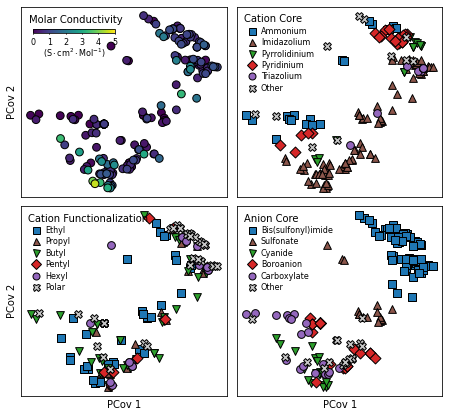

In [20]:
mark_size = 60

#fig,ax2=plt.subplot_mosaic('AB',figsize=(7.0866, 2.75), facecolor='white')
fig,ax2=plt.subplot_mosaic('AB;CD',figsize=(6.5, 6), facecolor='white')

an_cat_labels = Bit_Matrix_Short.copy()

ax2['B'].grid(color='gray',axis='both',alpha=0.0)
ax2['B'].set_axisbelow(True)
ax2['B'].tick_params(left=True, bottom=True, labelleft = True, labelbottom=True, labelsize=8)
ax2['B'].set_facecolor('w')

cation_colors = {
    'Ammonium': '#1F77B4',
    'Imidazolium': '#8c564b',
    'Pyrrolidinium': '#2CA02C',
    # 'Piperidinium': 'green',
    'Pyridinium': '#D62728',
    'Triazolium': '#9467BD',
    'Other': '#C7C7C7',
}

anion_shapes = {

    'Ammonium': 's',      # Square
    'Imidazolium': '^',     # Triangle up
    'Pyrrolidinium': 'v',     # Triangle down
    'Pyridinium': 'D',    # Diamond
    'Triazolium': 'o',    # Circle
    'Other': 'X',
}

# cation plot mapping
cation_map = {
    'Ammonium': an_cat_labels[['0_c', '3_c']].any(axis=1),
    'Imidazolium': an_cat_labels['5_c'] == 1,
    'Pyrrolidinium': an_cat_labels['4_c'] == 1,
    #'Piperidinium': an_cat_labels['7_c'] == 1,
    'Pyridinium': an_cat_labels['8_c'] == 1,
    'Triazolium': an_cat_labels['12_c'] == 1,
    'Other': ~an_cat_labels[['5_c', '4_c', '8_c', '0_c', '3_c', '12_c']].any(axis=1),

}

# anion plot mapping
anion_map = {
    'Ammonium': an_cat_labels[['0_c', '3_c']].any(axis=1),
    'Imidazolium': an_cat_labels['5_c'] == 1,
    'Pyrrolidinium': an_cat_labels['4_c'] == 1,
    #'Piperidinium': an_cat_labels['7_c'] == 1,
    'Pyridinium': an_cat_labels['8_c'] == 1,
    'Triazolium': an_cat_labels['12_c'] == 1,
    'Other': ~an_cat_labels[['5_c', '4_c', '8_c', '0_c', '3_c', '12_c']].any(axis=1)

}

for cation, cation_mask in cation_map.items():
    for anion, anion_mask in anion_map.items():
        mask = cation_mask & anion_mask
        ax2['B'].scatter(pd.DataFrame(T_pcovr_maccs)[mask].iloc[:,0], 
                    pd.DataFrame(T_pcovr_maccs)[mask].iloc[:,1], 
                    c=cation_colors[cation], 
                    marker=anion_shapes[anion], edgecolors='k', alpha=1, s=mark_size
                    )

#ax2['A'].plot([-1,6], [-1, 6], color='black')
# ax2['A'].set_xlabel('Predicted Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)',fontsize = 10)
# ax2['A'].set_ylabel('Actual Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', fontsize = 10)
# ax2['A'].set_xlim(-1.5,0.75)
# ax2['A'].set_ylim(-1.5,3)
#ax2['A'].set_title('Cation and Anion Paired Performance',fontsize = 18)

# Manually create legend handles and labels
legend_handles = []
legend_labels = []

# cations:
for cation, color in cation_colors.items():
    for anion, shape in anion_shapes.items():
        if cation == anion:
            handle = plt.Line2D([0], [0], color='w', markerfacecolor=color, marker=shape, markersize=10, markeredgecolor='k', markeredgewidth=1)
            legend_handles.append(handle)
            legend_labels.append(cation)

# LEGEND???
ax2['B'].legend(legend_handles, legend_labels, frameon=True, framealpha=0.0, fontsize=8, markerscale=0.7, labelspacing=0.3, handletextpad=0.1, ncol=1, columnspacing=0, loc=2, title='Cation Core', alignment='left', title_fontsize=10)

plt.subplots_adjust(left=0.1, right=0.8, 
                    top=0.9, bottom=0, 
                    wspace=0.05, hspace=0.1)





an_cat_labels = Bit_Matrix_Short.copy()

ax2['C'].grid(color='gray',axis='both',alpha=0.0)
ax2['C'].set_axisbelow(True)
ax2['C'].tick_params(left=True, bottom=True, labelleft = True, labelbottom=True, labelsize=8)
ax2['C'].set_facecolor('w')

cation_colors = {
    'Ethyl': '#1F77B4',
    'Propyl': '#8c564b',
    'Butyl': '#2CA02C',
    'Pentyl': '#D62728',
    'Hexyl': '#9467BD',
    'Polar': '#C7C7C7',
}

anion_shapes = {

    'Ethyl': 's',      # Square
    'Propyl': '^',     # Triangle up
    'Butyl': 'v',     # Triangle down
    'Pentyl': 'D',    # Diamond
    'Hexyl': 'o',    # Circle
    'Polar': 'X',
}

# cation plot mapping
cation_map = {
    'Ethyl': ~an_cat_labels[['15_c', '16_c', '19_c', '20_c', '21_c', '22_c', '30_c', '32_c']].any(axis=1),
    'Propyl': (~an_cat_labels[['15_c', '16_c', '20_c', '21_c', '22_c', '30_c', '32_c']].any(axis=1)) & (an_cat_labels['19_c'] == 1),
    'Butyl': (~an_cat_labels[['15_c', '16_c', '21_c', '22_c', '30_c', '32_c']].any(axis=1)) & (an_cat_labels['20_c'] == 1),
    'Pentyl': (~an_cat_labels[['15_c', '16_c', '22_c', '30_c', '32_c']].any(axis=1)) & (an_cat_labels['21_c'] == 1),
    'Hexyl': (~an_cat_labels[['15_c', '16_c', '30_c', '32_c']].any(axis=1)) & (an_cat_labels['22_c'] == 1),
    'Polar': an_cat_labels[['15_c', '30_c']].any(axis=1)
}

# anion plot mapping
anion_map = {
    'Ethyl': ~an_cat_labels[['15_c', '16_c', '19_c', '20_c', '21_c', '22_c', '30_c', '32_c']].any(axis=1),
    'Propyl': (~an_cat_labels[['15_c', '16_c', '20_c', '21_c', '22_c', '30_c', '32_c']].any(axis=1)) & (an_cat_labels['19_c'] == 1),
    'Butyl': (~an_cat_labels[['15_c', '16_c', '21_c', '22_c', '30_c', '32_c']].any(axis=1)) & (an_cat_labels['20_c'] == 1),
    'Pentyl': (~an_cat_labels[['15_c', '16_c', '22_c', '30_c', '32_c']].any(axis=1)) & (an_cat_labels['21_c'] == 1),
    'Hexyl': (~an_cat_labels[['15_c', '16_c', '30_c', '32_c']].any(axis=1)) & (an_cat_labels['22_c'] == 1),
    'Polar': an_cat_labels[['15_c', '30_c']].any(axis=1)
}

for cation, cation_mask in cation_map.items():
    for anion, anion_mask in anion_map.items():
        mask = cation_mask & anion_mask
        ax2['C'].scatter(pd.DataFrame(T_pcovr_maccs)[mask].iloc[:,0], 
                    pd.DataFrame(T_pcovr_maccs)[mask].iloc[:,1], 
                    c=cation_colors[cation], 
                    marker=anion_shapes[anion], edgecolors='k', alpha=1, s=mark_size
                    )

#ax2['A'].plot([-1,6], [-1, 6], color='black')
# ax2['A'].set_xlabel('Predicted Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)',fontsize = 10)
# ax2['A'].set_ylabel('Actual Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', fontsize = 10)
# ax2['C'].set_xlim(-1.5,0.75)
# ax2['C'].set_ylim(-1.5,3)
#ax2['A'].set_title('Cation and Anion Paired Performance',fontsize = 18)

# Manually create legend handles and labels
legend_handles = []
legend_labels = []


for cation, color in cation_colors.items():
    for anion, shape in anion_shapes.items():
        if cation == anion:
            handle = plt.Line2D([0], [0], color='w', markerfacecolor=color, marker=shape, markersize=10, markeredgecolor='k', markeredgewidth=1)
            legend_handles.append(handle)
            legend_labels.append(cation)


# LEGEND???
ax2['C'].legend(legend_handles, legend_labels, frameon=True, framealpha=0.0, fontsize=8, markerscale=0.7, labelspacing=0.3, handletextpad=0.1, ncol=1, columnspacing=0, loc=2, title='Cation Functionalization', alignment='left', title_fontsize=10)

# plt.subplots_adjust(left=0.1, right=0.9, 
#                     top=0.9, bottom=0.1, 
#                     wspace=0.125, hspace=0.1)




an_cat_labels = Bit_Matrix_Short.copy()

ax2['D'].grid(color='gray',axis='both',alpha=0.0)
ax2['D'].set_axisbelow(True)
ax2['D'].tick_params(left=True, bottom=True, labelleft = True, labelbottom=True, labelsize=8)
ax2['D'].set_facecolor('w')

cation_colors = {
    'Bis(sulfonyl)imide': '#1F77B4',
    'Sulfonate': '#8c564b',
    'Cyanide': '#2CA02C',
    'Boroanion': '#D62728',
    'Carboxylate': '#9467BD',
    'Other': '#C7C7C7',
}

anion_shapes = {

    'Bis(sulfonyl)imide': 's',      # Square
    'Sulfonate': '^',     # Triangle up
    'Cyanide': 'v',     # Triangle down
    'Boroanion': 'D',    # Diamond
    'Carboxylate': 'o',
    'Other': 'X',    # Circle
}

# cation plot mapping
cation_map = {
    'Bis(sulfonyl)imide': an_cat_labels['37_a'] == 1,
    'Sulfonate': an_cat_labels['38_a'] == 1,
    'Cyanide': an_cat_labels['39_a'] == 1,
    'Boroanion': an_cat_labels['45_a'] == 1,
    'Carboxylate': an_cat_labels['40_a'] ==1,
    'Other': ~an_cat_labels[['37_a', '38_a', '39_a', '40_a', '45_a']].any(axis=1),
}

# anion plot mapping
anion_map = {
    'Bis(sulfonyl)imide': an_cat_labels['37_a'] == 1,
    'Sulfonate': an_cat_labels['38_a'] == 1,
    'Cyanide': an_cat_labels['39_a'] == 1,
    'Boroanion': an_cat_labels['45_a'] == 1,
    'Carboxylate': an_cat_labels['40_a'] ==1,
    'Other': ~an_cat_labels[['37_a', '38_a', '39_a', '40_a', '45_a']].any(axis=1),
}

for cation, cation_mask in cation_map.items():
    for anion, anion_mask in anion_map.items():
        mask = cation_mask & anion_mask
        ax2['D'].scatter(pd.DataFrame(T_pcovr_maccs)[mask].iloc[:,0], 
                    pd.DataFrame(T_pcovr_maccs)[mask].iloc[:,1], 
                    c=cation_colors[cation], 
                    marker=anion_shapes[anion], edgecolors='k', alpha=1, s=mark_size
                    )

#ax2['A'].plot([-1,6], [-1, 6], color='black')
# ax2['A'].set_xlabel('Predicted Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)',fontsize = 10)
# ax2['A'].set_ylabel('Actual Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', fontsize = 10)

#ax2['A'].set_title('Cation and Anion Paired Performance',fontsize = 18)

# Manually create legend handles and labels
legend_handles = []
legend_labels = []

# cations:
for cation, color in cation_colors.items():
    for anion, shape in anion_shapes.items():
        if cation == anion:
            handle = plt.Line2D([0], [0], color='w', markerfacecolor=color, marker=shape, markersize=10, markeredgewidth=1, markeredgecolor='k')
            legend_handles.append(handle)
            legend_labels.append(cation)

# LEGEND???
ax2['D'].legend(legend_handles, legend_labels, frameon=True, framealpha=0.0, fontsize=8, markerscale=0.7, labelspacing=0.3, handletextpad=0.1, ncol=1, columnspacing=0, loc=2, title='Anion Core', alignment='left', title_fontsize=10)

plt.subplots_adjust(left=0.05, right=0.95, 
                    top=0.95, bottom=0.05, 
                    wspace=0.05, hspace=0.05)


im = ax2['A'].scatter(Sorted_TC_Maccs[0], Sorted_TC_Maccs[1], c=Sorted_TC_Maccs['molarCond_Scm2mol'], edgecolor='k', s=mark_size, linewidth=1, vmin=0, vmax=5)
ax2['A'].annotate('Molar Conductivity', xy=(0.04,0.96), xycoords='axes fraction', size=10, ha='left', va='top')



cb_ax = fig.add_axes([0.075, 0.89, 0.175, 0.01])
cbar = fig.colorbar(im, cax=cb_ax, shrink = 1, pad=0, orientation='horizontal')
cbar.set_label(label='($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', size=8, labelpad=0)
cbar.set_ticks([0,1,2,3,4,5])
cbar.ax.tick_params(axis='both', which='major', length=1, width=1) # Adjust values as needed
cbar.ax.tick_params(labelsize=8)




for axes in ['A', 'B', 'C', 'D']:
    ax2[axes].set_xticks([])
    ax2[axes].set_yticks([])
    ax2[axes].set_facecolor('white')
    # ax2[axes].set_xlim(-1.5,0.65)
    # ax2[axes].set_ylim(-1.5,2.5)

for axes in ['C','D']:
    ax2[axes].set_xlabel('PCov 1', size=10)

for axes in ['A','C']:
    ax2[axes].set_ylabel('PCov 2', size=10)

plt.savefig('../Figures/MACCS PCovR.png', dpi=150)

plt.show()